<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_DeepDive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

In [10]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
#import pandas_ta as ta
import numpy as np
import time
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress
import ta
print("Libraries Installed!")

0.2.66
Libraries Installed!


# Monthly Win-rate for SP500

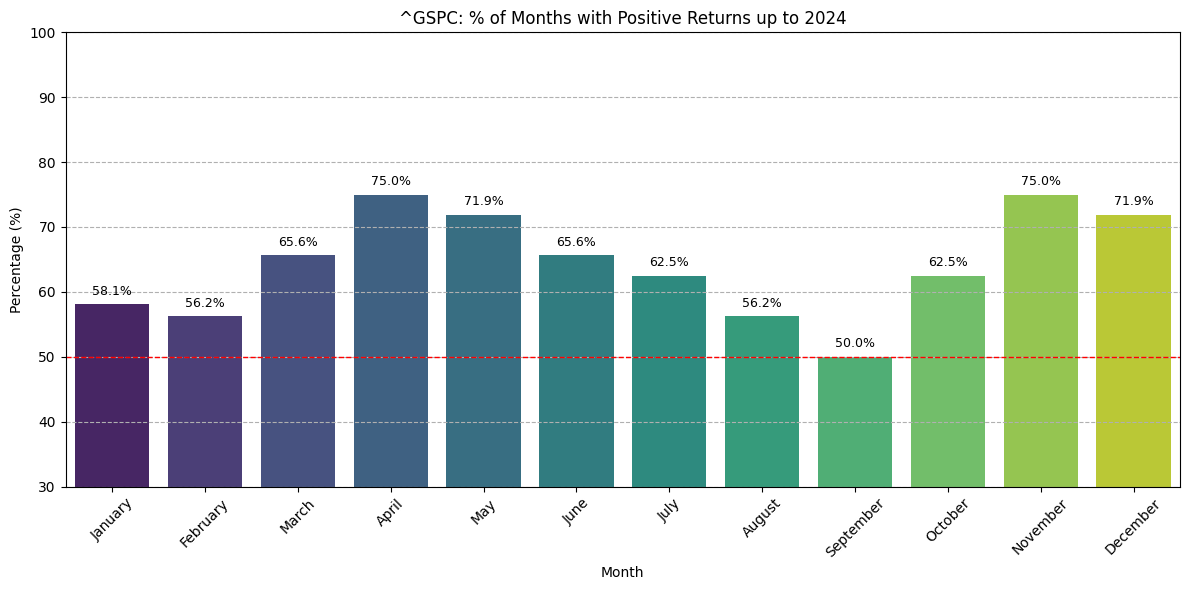

In [11]:
# Step 1: Download SPY historical data
ticker= '^GSPC' # '^DJI', '^IXIC'
spy = yf.download(ticker, start="1993-01-01", end="2024-12-31", progress=False,auto_adjust=False)

# Step 2: Resample to monthly data and calculate returns
spy_monthly = spy['Close'].resample('ME').last()
monthly_returns = spy_monthly.pct_change().dropna()


# Step 3: Extract month names and whether return was positive
monthly_returns.columns = ['Return']
monthly_returns_df = monthly_returns.copy()
monthly_returns_df['Month'] = monthly_returns_df.index.month_name()
monthly_returns_df['Positive'] = monthly_returns_df['Return'] > 0


# Step 4: Group by month and calculate percent positive
positive_rate = (
    monthly_returns_df.groupby('Month')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Step 5: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
positive_rate['Month'] = pd.Categorical(positive_rate['Month'], categories=month_order, ordered=True)
positive_rate = positive_rate.sort_values('Month')

# Step 6: Plot using Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=positive_rate,
    x='Month',
    y='Percent Positive',
    hue='Month',
    palette='viridis',
    legend=False
)

# Annotate each bar with the exact value
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')
plt.xticks(rotation=45)
plt.title("{}: % of Months with Positive Returns up to 2024".format(ticker))
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()


#monthly_returns_df.head()

Days of Week

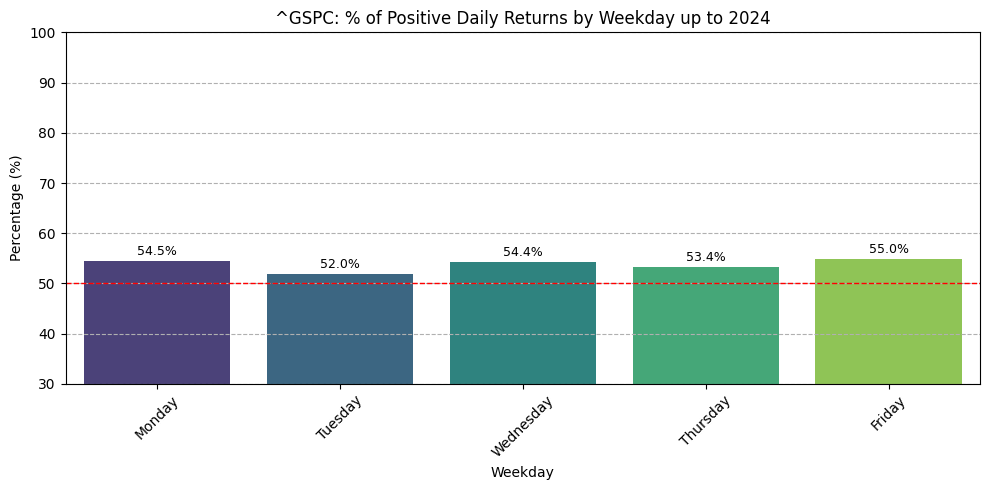

In [12]:
# Step 1: Download SPY historical data
spy = yf.download(ticker, start="1993-01-01", end="2024-12-31", progress=False,auto_adjust=False)

# Step 2: calculate daily returns
spy['Return'] = spy['Close'].pct_change()
spy = spy.dropna()


# Step 3: Add weekday column
spy['Weekday'] = spy.index.day_name()
spy['Positive'] = spy['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    spy.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("{}: % of Positive Daily Returns by Weekday up to 2024".format(ticker))
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# IWM daily positivit expentacy

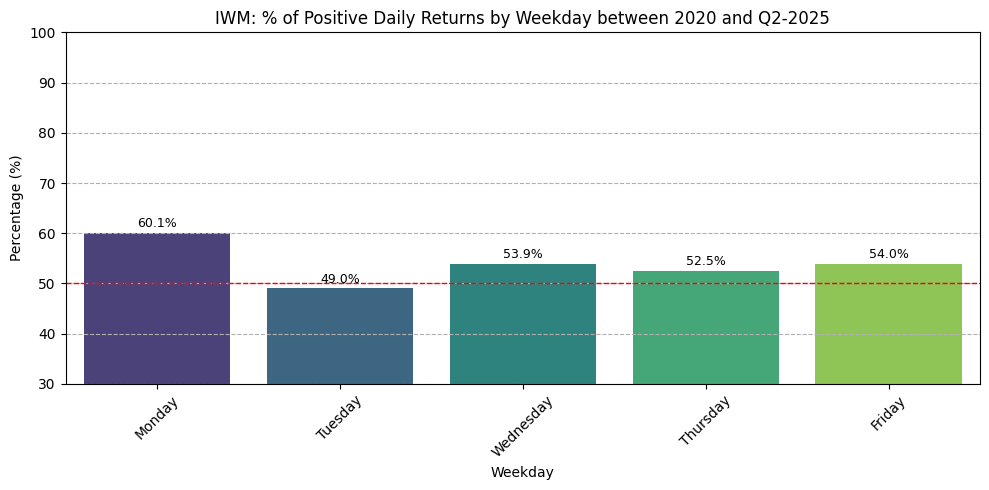

In [13]:
# Step 1: Download SPY historical data
ticker2= 'IWM'
iwm = yf.download(ticker2, start="2020-01-01", end="2025-06-30", progress=False,auto_adjust=False)

# Step 2: calculate daily returns
iwm['Return'] = spy['Close'].pct_change()
iwm = iwm.dropna()


# Step 3: Add weekday column
iwm['Weekday'] = iwm.index.day_name()
iwm['Positive'] = iwm['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    iwm.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("{}: % of Positive Daily Returns by Weekday between 2020 and Q2-2025".format(ticker2))
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# 4-Year Presidential Cycle

[*********************100%***********************]  1 of 1 completed


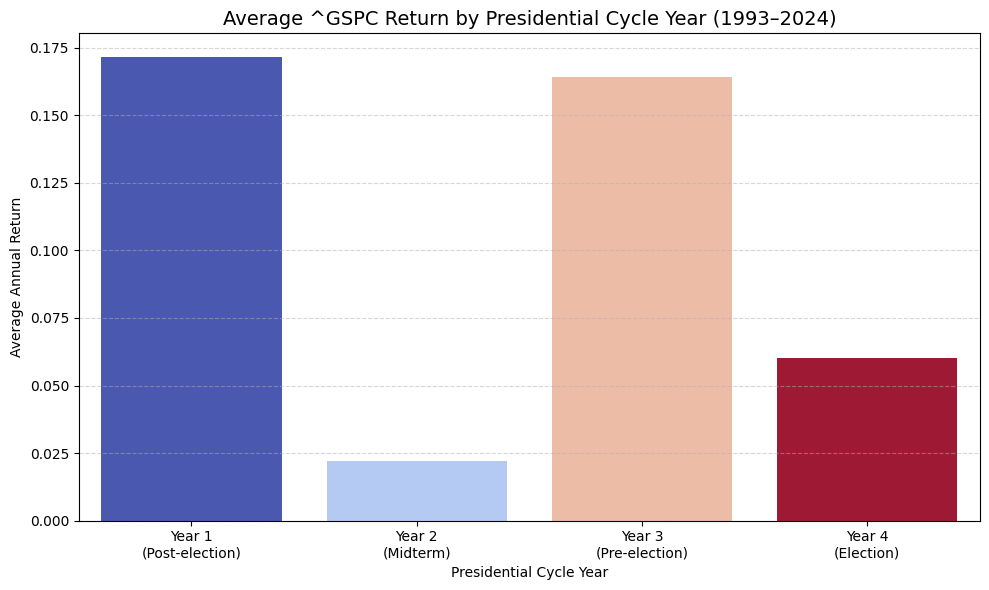

In [14]:

spy = yf.download(ticker, start="1900-01-01", end="2024-12-31", interval="1mo", auto_adjust=False)
spy['Year'] = spy.index.year

# Step 2: Extract year-end closing prices
yearly_close = spy.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Step 4: Assign presidential cycle year (1993 = Year 1)
def get_cycle_year(year):
    return ((year - 1993) % 4) + 1

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)
plt.title('Average {} Return by Presidential Cycle Year (1993–2024)'.format(ticker), fontsize=14)
plt.xlabel('Presidential Cycle Year')
plt.ylabel('Average Annual Return')
plt.xticks([0, 1, 2, 3], ['Year 1\n(Post-election)', 'Year 2\n(Midterm)', 'Year 3\n(Pre-election)', 'Year 4\n(Election)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [15]:
# Optional: Display table
cycle_stats.round(4)

,CycleYear,mean,median,std,count
0,1,0.1718,0.2345,0.1501,9
1,2,0.0219,0.0493,0.1621,10
2,3,0.1643,0.2188,0.1363,10
3,4,0.0600,0.1097,0.1816,10


[*********************100%***********************]  1 of 1 completed


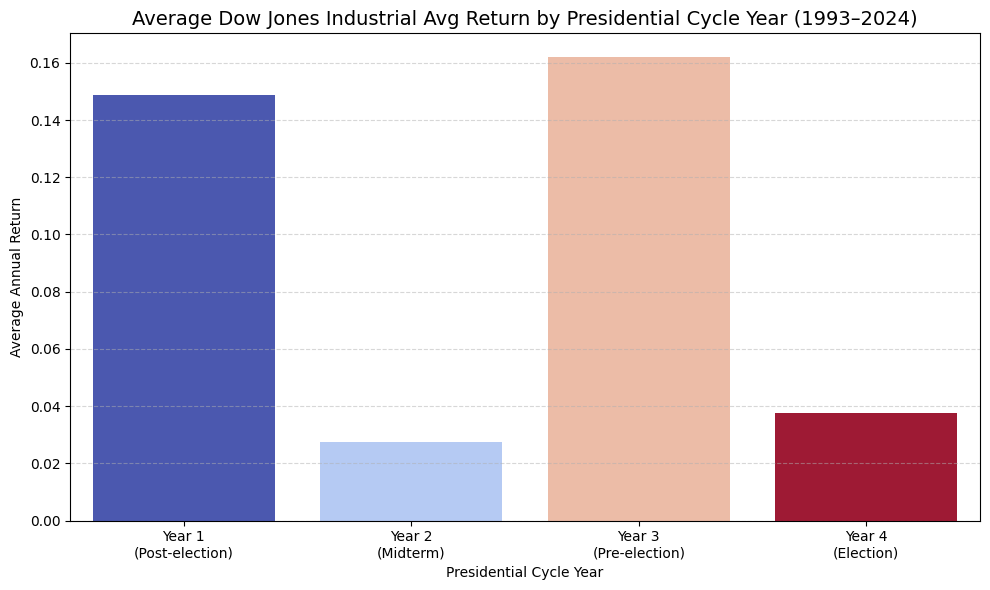

In [16]:
#Dow Jones Industrial Avg
dji = yf.download("^DJI", start="1993-01-01", end="2024-12-31", interval="1mo", auto_adjust=False)
dji['Year'] = dji.index.year

# Step 2: Extract year-end closing prices
yearly_close = dji.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Step 4: Assign presidential cycle year (1993 = Year 1)
def get_cycle_year(year):
    return ((year - 1993) % 4) + 1

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)
plt.title('Average Dow Jones Industrial Avg Return by Presidential Cycle Year (1993–2024)', fontsize=14)
plt.xlabel('Presidential Cycle Year')
plt.ylabel('Average Annual Return')
plt.xticks([0, 1, 2, 3], ['Year 1\n(Post-election)', 'Year 2\n(Midterm)', 'Year 3\n(Pre-election)', 'Year 4\n(Election)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Weinstien Stages by Week for SP500

In [17]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers


def rolling_regression_slope(series, window=30):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    #data['SMA_prev'] = data['SMA_30'].shift(1)
    #data['SMA_slope'] = data['SMA_30'] - data['SMA_prev']
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [1, 2, 3, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Week', 'Stage']).size().unstack(fill_value=0)

    return stage_counts, combined_df


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    stage_counts, combined_df = aggregate_stage_counts(tickers)
    print(stage_counts.tail())

Loaded 503 tickers
Stage       1.0  2.0  3.0  4.0
Week                          
2025-09-29   45  188  156  106
2025-10-06   63  181  102  149
2025-10-13   65  186  118  126
2025-10-20   60  192  130  113
2025-10-27   91  170   99  135


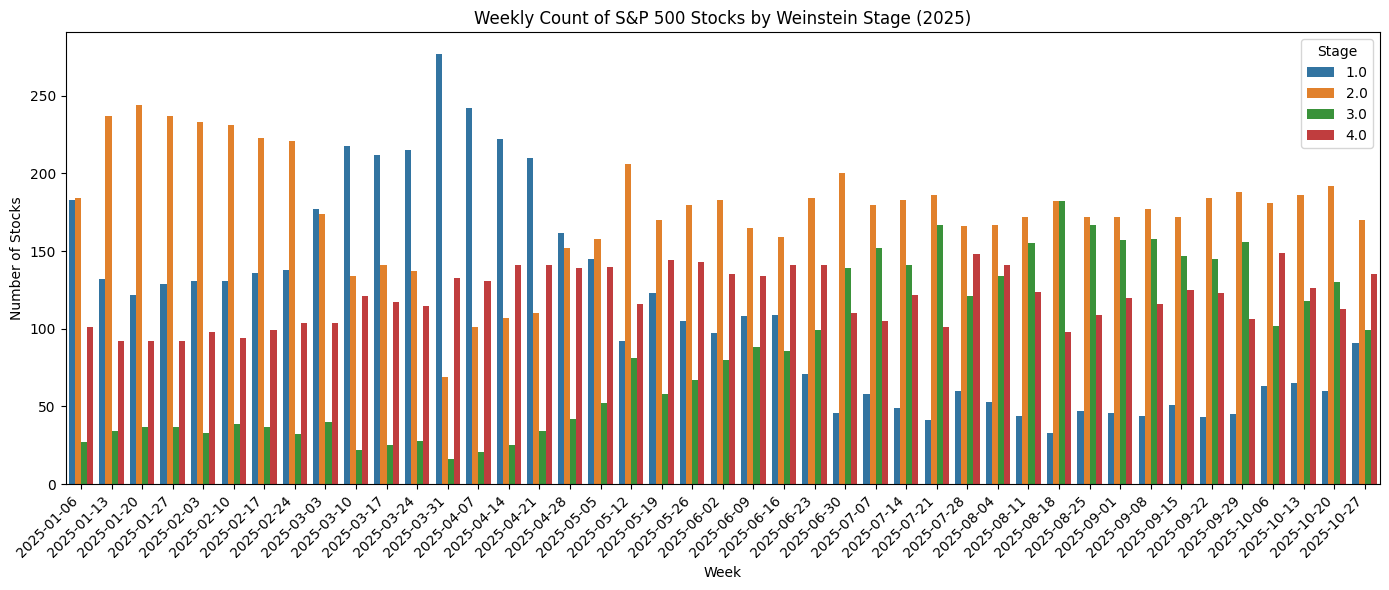

In [18]:
 # Plot stage distribution by week
plt.figure(figsize=(14, 6))
sns.countplot(data=combined_df, x='Week', hue='Stage', palette='tab10')
plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)")
plt.xlabel("Week")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title="Stage")
plt.show()

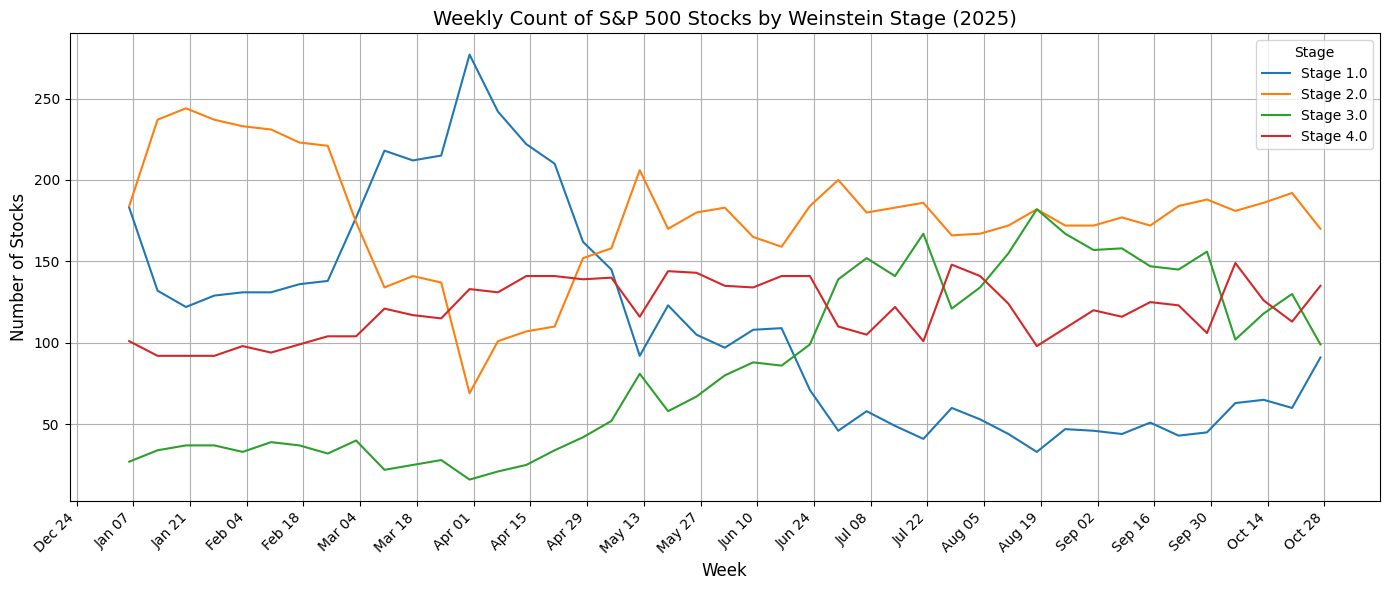

In [19]:
# plot line chart
stage_counts_reset = stage_counts.reset_index()

plt.figure(figsize=(14, 6))

for stage in stage_counts.columns:
    plt.plot(stage_counts_reset['Week'], stage_counts_reset[stage], label=f"Stage {stage}")

plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Stocks", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage")
plt.tight_layout()
plt.grid(True)
plt.show()

# Combining Stages 1 for SP500 Stocks

In [20]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=30):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    #stages = [2, 2, 4, 4]
    stages = [1, 2, 3, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([1,2,3, 4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [1,2,3, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        1: "Basing Stocks",
        2: "Advancing Stocks",
        3: "Topping Stocks",
        4: "Declining Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Basing Stocks  Advancing Stocks  Topping Stocks  Declining Stocks
Week                                                                         
2025-09-29           9.09             37.98           31.52             21.41
2025-10-06          12.73             36.57           20.61             30.10
2025-10-13          13.13             37.58           23.84             25.45
2025-10-20          12.12             38.79           26.26             22.83
2025-10-27          18.38             34.34           20.00             27.27


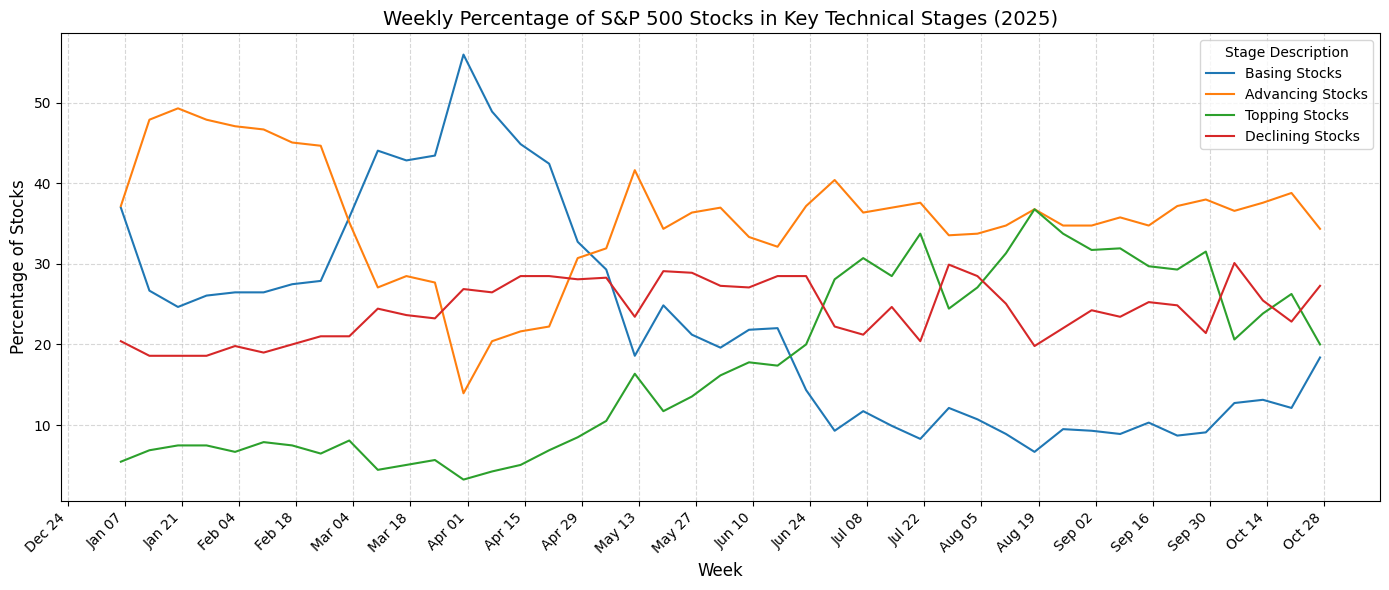

In [21]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Adavancing/Basing vs Topping/Declining Phase

In [22]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

def rolling_regression_slope(series, window=30):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [2, 2, 4, 4]

    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2,4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Basing or Advancing Stocks",
        4: "Topping or Declining Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 503 tickers
Stage       Basing or Advancing Stocks  Topping or Declining Stocks
Week                                                               
2025-09-29                       47.07                        52.93
2025-10-06                       49.29                        50.71
2025-10-13                       50.71                        49.29
2025-10-20                       50.91                        49.09
2025-10-27                       52.73                        47.27


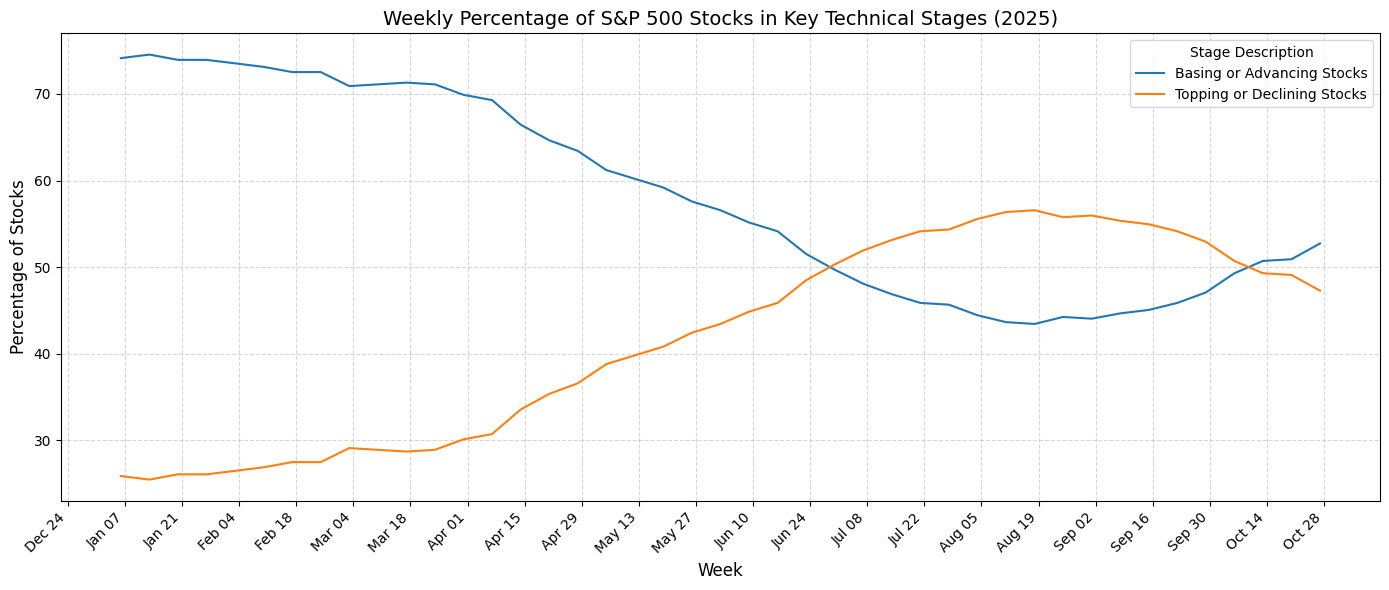

In [23]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P 500 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


 ## Filter stocks by stages 2 and 4

# Confirm Stages by Week

In [24]:
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers


def rolling_regression_slope(series, window=30):
    """
    Returns the slope of linear regression over a rolling window.
    This is the TRUE slope of the trend.
    """
    def calc_slope(window_series):
        if len(window_series) < window or window_series.isna().any():
            return np.nan
        y = window_series.values
        x = np.arange(len(y))
        return linregress(x, y).slope

    return series.rolling(window).apply(calc_slope, raw=False)


def classify_stages_weekly(ticker):
    import yfinance as yf
    import numpy as np
    import pandas as pd

    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        return None

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    data = data.bfill()

    #data['SMA_prev'] = data['SMA_30'].shift(1)
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()
    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),  # Stage 1
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),   # Stage 2
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),  # Stage 3
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)    # Stage 4
    ]
    stages = [1, 2, 3, 4]

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    #data = data.dropna(subset=['Stage'])

    # Filter for 2025 only
    data = data[data.index.year == 2025]
    if data.empty:
        return None

    latest = data.iloc[-1]
    return pd.DataFrame({
        'Ticker': [ticker],
        'Week': [latest.name.strftime('%Y-%m-%d')],
        'Stage': [int(latest['Stage'].iloc[0]) if isinstance(latest['Stage'], pd.Series) else int(latest['Stage'])]
    })

def get_weekly_stage_screener(tickers):
    results = []
    for ticker in tickers:
        res = classify_stages_weekly(ticker)
        if res is not None:
            results.append(res)

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame(columns=['Ticker', 'Week', 'Stage'])


if __name__ == "__main__":
    import pandas as pd

    tickers = get_sp500_tickers()
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [t for t in tickers if t not in excluded]

    screener_df = get_weekly_stage_screener(tickers)
    print("All weekly results (latest 2025):")
    print(screener_df.head())

    # Filter for bullish or bearish trends (Stage 2 and 3)
    filtered_df = screener_df[screener_df['Stage'].isin([2, 4])]
    print(f"\nFiltered (Stage 2 & 4):\n{filtered_df}")

    # Save to CSV
    filtered_df.to_csv("weekly_stage_2_4_stocks_2025.csv", index=False)
    print("\nSaved to 'weekly_stage_2_4_stocks_2025.csv'")

All weekly results (latest 2025):
  Ticker        Week  Stage
0   NVDA  2025-10-27      2
1   MSFT  2025-10-27      2
2   AAPL  2025-10-27      3
3   GOOG  2025-10-27      2
4  GOOGL  2025-10-27      2

Filtered (Stage 2 & 4):
    Ticker        Week  Stage
0     NVDA  2025-10-27      2
1     MSFT  2025-10-27      2
3     GOOG  2025-10-27      2
4    GOOGL  2025-10-27      2
5     AMZN  2025-10-27      2
..     ...         ...    ...
488   HSIC  2025-10-27      4
489    MHK  2025-10-27      4
490    LKQ  2025-10-27      4
493    EMN  2025-10-27      4
494    KMX  2025-10-27      4

[305 rows x 3 columns]

Saved to 'weekly_stage_2_4_stocks_2025.csv'


# Weinstien Stages by Week for S&P/ASX 200

In [26]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp200_tickers():
    df = pd.read_csv('ASX200.csv')
    tickers = df['ticks'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [1, 2, 3, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Week', 'Stage']).size().unstack(fill_value=0)

    return stage_counts, combined_df


# Main
if __name__ == "__main__":
    tickers = get_sp200_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    stage_counts, combined_df = aggregate_stage_counts(tickers)
    print(stage_counts.tail())

Loaded 196 tickers
Not enough data for DNL.AX
Not enough data for VGN.AX
Not enough data for SOLDA.AX
Not enough data for GGP.AX
Stage       1.0  2.0  3.0  4.0
Week                          
2025-09-29   23   88   46   34
2025-10-06   22   94   44   31
2025-10-13   26   91   43   32
2025-10-20   23   97   44   27
2025-10-27   30   93   37   31


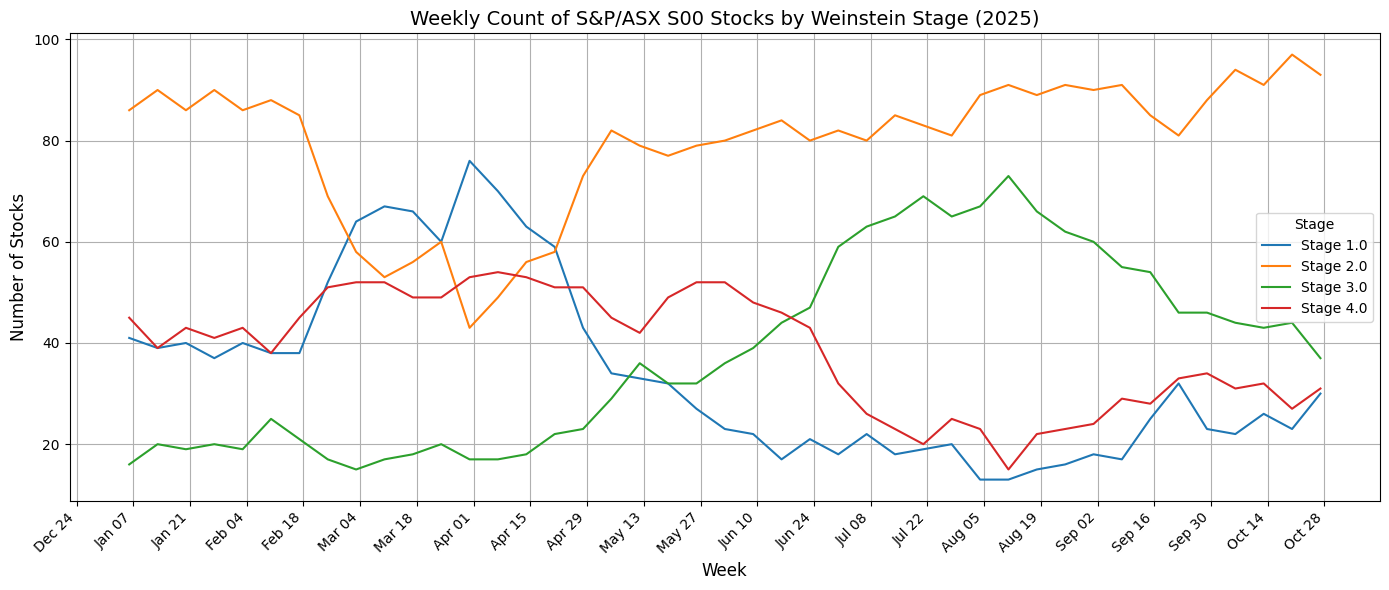

In [27]:
# plot line chart
stage_counts_reset = stage_counts.reset_index()

plt.figure(figsize=(14, 6))

for stage in stage_counts.columns:
    plt.plot(stage_counts_reset['Week'], stage_counts_reset[stage], label=f"Stage {stage}")

plt.title("Weekly Count of S&P/ASX S00 Stocks by Weinstein Stage (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Stocks", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage")
plt.tight_layout()
plt.grid(True)
plt.show()

# Combining Stages 1 for S&P/ASX 200 Stocks

In [28]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp200_tickers():
    df = pd.read_csv('ASX200.csv')
    tickers = df['ticks'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False,auto_adjust=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_slope'] = rolling_regression_slope(data['SMA_30'], window=30)
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [2, 2, 4, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_percentages(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            result['Ticker'] = ticker
            all_data.append(result)

    if not all_data:
        return None, None

    combined_df = pd.concat(all_data)

    # Count number of tickers per week
    total_per_week = combined_df.groupby('Week')['Ticker'].nunique()

    # Count number of tickers in Stage 2 or 4
    stage_filtered = combined_df[combined_df['Stage'].isin([2, 4])]
    stage_counts = stage_filtered.groupby(['Week', 'Stage'])['Ticker'].nunique().unstack(fill_value=0)

    # Add missing stage columns if needed
    for s in [2, 4]:
        if s not in stage_counts.columns:
            stage_counts[s] = 0

    # Calculate percentage
    percentage_df = stage_counts.div(total_per_week, axis=0) * 100
    # Map numeric stage to descriptions
    stage_map = {
        2: "Basing or Advancing Stocks",
        4: "Topping or Declining Stocks"
    }
    # Rename columns using stage_map
    percentage_df = percentage_df.rename(columns=stage_map)

    return percentage_df.round(2), combined_df,stage_counts


# Main
if __name__ == "__main__":
    tickers = get_sp200_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    percentage_df, combined_df,stage_count = aggregate_stage_percentages(tickers)
    print(percentage_df.tail())

Loaded 196 tickers
Not enough data for DNL.AX
Not enough data for VGN.AX
Not enough data for SOLDA.AX
Not enough data for GGP.AX
Stage       Basing or Advancing Stocks  Topping or Declining Stocks
Week                                                               
2025-09-29                       58.12                        41.88
2025-10-06                       60.73                        39.27
2025-10-13                       60.94                        39.06
2025-10-20                       62.83                        37.17
2025-10-27                       64.40                        35.60


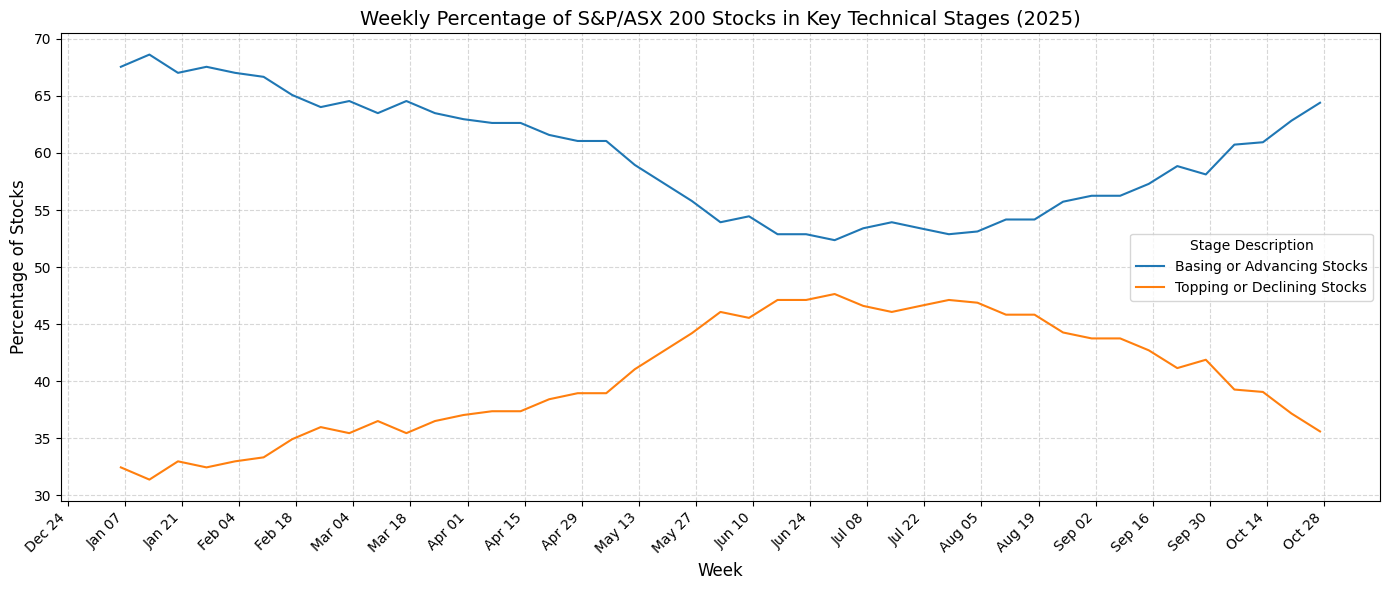

In [29]:
stage_count_reset = stage_count.reset_index()  # Remove the 'Stage' label
plt.figure(figsize=(14, 6))

# Loop through each descriptive column name (e.g., "Basing or Advancing Stocks")
for stage_label in percentage_df.columns:
    plt.plot(stage_count_reset['Week'], percentage_df[stage_label], label=stage_label)

plt.title("Weekly Percentage of S&P/ASX 200 Stocks in Key Technical Stages (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Percentage of Stocks", fontsize=12)

# Format x-axis to show every 2nd week
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage Description")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()